In [2]:
import pandas as pd    # to handle data
import numpy as np     # for mathematical computation
import matplotlib.pyplot as plt  # Visualization
import seaborn as sns            # Visualization
import warnings                  # Keeps the workspace clean
warnings.filterwarnings("ignore")  

In [3]:
dataset = pd.read_csv("../DataSet/T1.csv/T1.csv")
dataset.head()

,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
0,01 01 2018 00:00,380.047791,5.311336,416.328908,259.994904
1,01 01 2018 00:10,453.769196,5.672167,519.917511,268.641113
2,01 01 2018 00:20,306.376587,5.216037,390.900016,272.564789
3,01 01 2018 00:30,419.645905,5.659674,516.127569,271.258087
4,01 01 2018 00:40,380.650696,5.577941,491.702972,265.674286


In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50530 entries, 0 to 50529
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Date/Time                      50530 non-null  object 
 1   LV ActivePower (kW)            50530 non-null  float64
 2   Wind Speed (m/s)               50530 non-null  float64
 3   Theoretical_Power_Curve (KWh)  50530 non-null  float64
 4   Wind Direction (°)             50530 non-null  float64
dtypes: float64(4), object(1)
memory usage: 1.9+ MB


In [6]:
dataset.describe()

,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
count,50530.000000,50530.000000,50530.000000,50530.000000
mean,1307.684332,7.557952,1492.175463,123.687559
std,1312.459242,4.227166,1368.018238,93.443736
min,-2.471405,0.000000,0.000000,0.000000
25%,50.677890,4.201395,161.328167,49.315437
50%,825.838074,7.104594,1063.776283,73.712978
75%,2482.507568,10.300020,2964.972462,201.696720
max,3618.732910,25.206011,3600.000000,359.997589


In [7]:
#dataset['Date/Time'] is object
dataset['Date/Time']=pd.to_datetime(dataset['Date/Time'], format = '%d %m %Y %H:%M')

In [8]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50530 entries, 0 to 50529
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Date/Time                      50530 non-null  datetime64[ns]
 1   LV ActivePower (kW)            50530 non-null  float64       
 2   Wind Speed (m/s)               50530 non-null  float64       
 3   Theoretical_Power_Curve (KWh)  50530 non-null  float64       
 4   Wind Direction (°)             50530 non-null  float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 1.9 MB


min in LV columns >>>> -2.471405
In Active power LV Describe() min value is negative that is mean that wind turbine sometimes is consuming power rather than generating it .
This situation can occur under several conditions:

1- Start-Up Phase: During the initial start-up phase, the turbine may draw power from the grid to initiate the rotation of the blades until the wind speed is sufficient for self-sustained operation.

2- Low Wind Conditions: When wind speeds are too low to generate sufficient power, the turbine may consume power to maintain its systems and control mechanisms.

3- Maintenance or Shutdown: During maintenance or shutdown periods, the turbine might use power for essential operations like braking systems, yaw control, and monitoring equipment.

4- Grid Support: In some cases, wind turbines can provide ancillary services to the grid, such as reactive power support or voltage regulation, which might involve consuming power temporarily.

Negative values in active power readings are a normal part of wind turbine operation under certain conditions and help operators understand the turbine's behavior and energy balance.

In [9]:
dataset.isna().sum()

Date/Time                        0
LV ActivePower (kW)              0
Wind Speed (m/s)                 0
Theoretical_Power_Curve (KWh)    0
Wind Direction (°)               0
dtype: int64

In [10]:
df = dataset.copy()
df.head()

,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
0,2018-01-01 00:00:00,380.047791,5.311336,416.328908,259.994904
1,2018-01-01 00:10:00,453.769196,5.672167,519.917511,268.641113
2,2018-01-01 00:20:00,306.376587,5.216037,390.900016,272.564789
3,2018-01-01 00:30:00,419.645905,5.659674,516.127569,271.258087
4,2018-01-01 00:40:00,380.650696,5.577941,491.702972,265.674286


In [11]:
df.tail()

,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
50525,2018-12-31 23:10:00,2963.980957,11.404030,3397.190793,80.502724
50526,2018-12-31 23:20:00,1684.353027,7.332648,1173.055771,84.062599
50527,2018-12-31 23:30:00,2201.106934,8.435358,1788.284755,84.742500
50528,2018-12-31 23:40:00,2515.694092,9.421366,2418.382503,84.297913
50529,2018-12-31 23:50:00,2820.466064,9.979332,2779.184096,82.274620


In [12]:
df['Month'] = df['Date/Time'].dt.month
df['Week']=df['Date/Time'].dt.isocalendar().week
df['Day']= df['Date/Time'].dt.day
df.head(20)

,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°),Month,Week,Day
0,2018-01-01 00:00:00,380.047791,5.311336,416.328908,259.994904,1,1,1
1,2018-01-01 00:10:00,453.769196,5.672167,519.917511,268.641113,1,1,1
2,2018-01-01 00:20:00,306.376587,5.216037,390.900016,272.564789,1,1,1
3,2018-01-01 00:30:00,419.645905,5.659674,516.127569,271.258087,1,1,1
4,2018-01-01 00:40:00,380.650696,5.577941,491.702972,265.674286,1,1,1
5,2018-01-01 00:50:00,402.391998,5.604052,499.436385,264.578613,1,1,1
6,2018-01-01 01:00:00,447.605713,5.793008,557.372363,266.163605,1,1,1
7,2018-01-01 01:10:00,387.242188,5.306050,414.898179,257.949493,1,1,1
8,2018-01-01 01:20:00,463.651215,5.584629,493.677652,253.480698,1,1,1
9,2018-01-01 01:30:00,439.725708,5.523228,475.706783,258.723785,1,1,1


In [13]:
df['Hour']=df['Date/Time'].dt.hour
df.head(100)

,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°),Month,Week,Day,Hour
0,2018-01-01 00:00:00,380.047791,5.311336,416.328908,259.994904,1,1,1,0
1,2018-01-01 00:10:00,453.769196,5.672167,519.917511,268.641113,1,1,1,0
2,2018-01-01 00:20:00,306.376587,5.216037,390.900016,272.564789,1,1,1,0
3,2018-01-01 00:30:00,419.645905,5.659674,516.127569,271.258087,1,1,1,0
4,2018-01-01 00:40:00,380.650696,5.577941,491.702972,265.674286,1,1,1,0
...,...,...,...,...,...,...,...,...,...
95,2018-01-01 15:50:00,2820.512939,10.772420,3186.029883,225.276398,1,1,1,15
96,2018-01-01 16:00:00,2812.279053,10.647520,3133.259224,224.680603,1,1,1,16
97,2018-01-01 16:10:00,2530.447021,9.982661,2781.274041,225.519501,1,1,1,16
98,2018-01-01 16:20:00,2399.121094,9.874386,2711.492458,227.273804,1,1,1,16


In [14]:
season_dict = {1 : 'Winter', 2: 'Winter', 3: 'Winter', 4 : 'Spring', 5: 'Spring', 6: 'Summer', 
               7:'Summer', 8:'Summer', 9:'Autumn', 10:'Autumn', 11:'Autumn', 12: 'Winter'}
df['Seasons']=df['Month'].map(season_dict)
df

,Date/Time,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°),Month,Week,Day,Hour,Seasons
0,2018-01-01 00:00:00,380.047791,5.311336,416.328908,259.994904,1,1,1,0,Winter
1,2018-01-01 00:10:00,453.769196,5.672167,519.917511,268.641113,1,1,1,0,Winter
2,2018-01-01 00:20:00,306.376587,5.216037,390.900016,272.564789,1,1,1,0,Winter
3,2018-01-01 00:30:00,419.645905,5.659674,516.127569,271.258087,1,1,1,0,Winter
4,2018-01-01 00:40:00,380.650696,5.577941,491.702972,265.674286,1,1,1,0,Winter
...,...,...,...,...,...,...,...,...,...,...
50525,2018-12-31 23:10:00,2963.980957,11.404030,3397.190793,80.502724,12,1,31,23,Winter
50526,2018-12-31 23:20:00,1684.353027,7.332648,1173.055771,84.062599,12,1,31,23,Winter
50527,2018-12-31 23:30:00,2201.106934,8.435358,1788.284755,84.742500,12,1,31,23,Winter
50528,2018-12-31 23:40:00,2515.694092,9.421366,2418.382503,84.297913,12,1,31,23,Winter


In [15]:
df.columns

Index(['Date/Time', 'LV ActivePower (kW)', 'Wind Speed (m/s)',
       'Theoretical_Power_Curve (KWh)', 'Wind Direction (°)', 'Month', 'Week',
       'Day', 'Hour', 'Seasons'],
      dtype='object')

In [16]:
columns_needed = ['LV ActivePower (kW)','Wind Speed (m/s)','Theoretical_Power_Curve (KWh)','Wind Direction (°)']


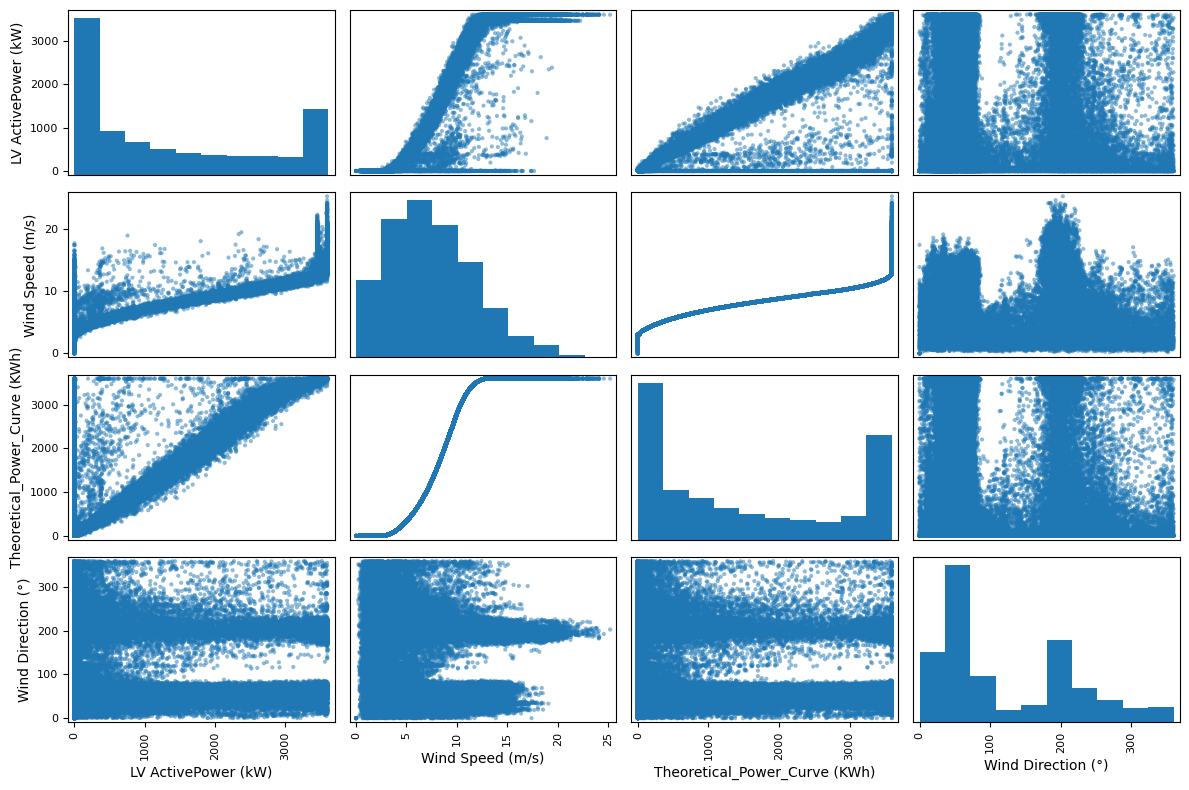

In [17]:
pd.plotting.scatter_matrix(df[columns_needed], figsize=(12,8))
plt.tight_layout()
plt.show()

array([[<Axes: title={'center': 'LV ActivePower (kW)'}>,
        <Axes: title={'center': 'Wind Speed (m/s)'}>],
       [<Axes: title={'center': 'Theoretical_Power_Curve (KWh)'}>,
        <Axes: title={'center': 'Wind Direction (°)'}>]], dtype=object)

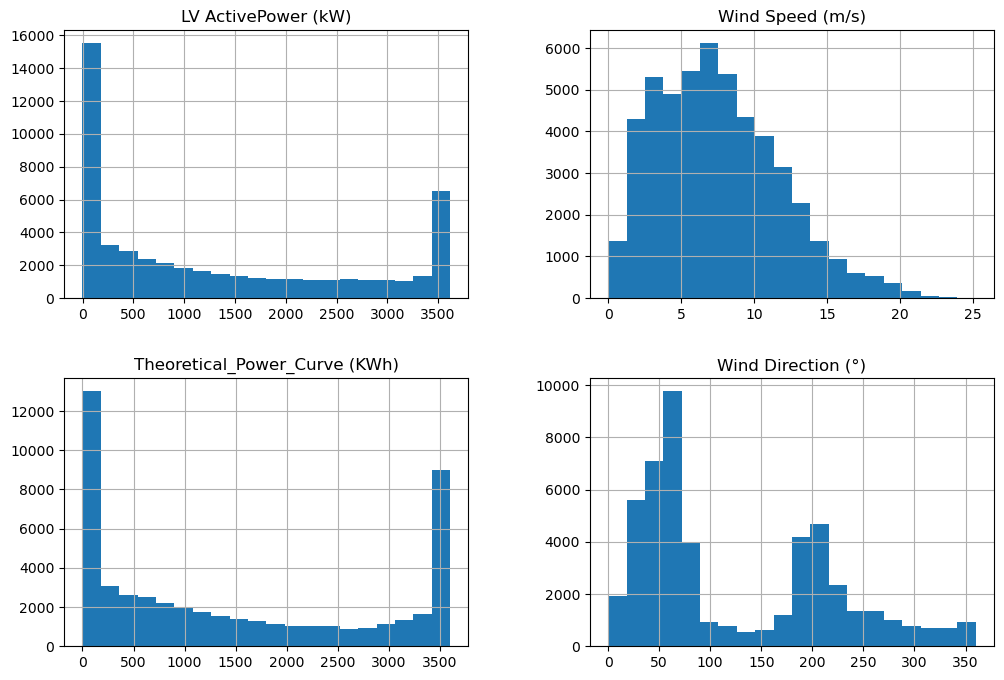

In [18]:
df[columns_needed].hist(bins = 20, figsize =(12, 8))

In [19]:
df.drop(columns = ['Date/Time'], inplace = True)
df

,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°),Month,Week,Day,Hour,Seasons
0,380.047791,5.311336,416.328908,259.994904,1,1,1,0,Winter
1,453.769196,5.672167,519.917511,268.641113,1,1,1,0,Winter
2,306.376587,5.216037,390.900016,272.564789,1,1,1,0,Winter
3,419.645905,5.659674,516.127569,271.258087,1,1,1,0,Winter
4,380.650696,5.577941,491.702972,265.674286,1,1,1,0,Winter
...,...,...,...,...,...,...,...,...,...
50525,2963.980957,11.404030,3397.190793,80.502724,12,1,31,23,Winter
50526,1684.353027,7.332648,1173.055771,84.062599,12,1,31,23,Winter
50527,2201.106934,8.435358,1788.284755,84.742500,12,1,31,23,Winter
50528,2515.694092,9.421366,2418.382503,84.297913,12,1,31,23,Winter


In [20]:
numeric_columns = df.select_dtypes(include = ['number']).columns
numeric_columns

Index(['LV ActivePower (kW)', 'Wind Speed (m/s)',
       'Theoretical_Power_Curve (KWh)', 'Wind Direction (°)', 'Month', 'Week',
       'Day', 'Hour'],
      dtype='object')

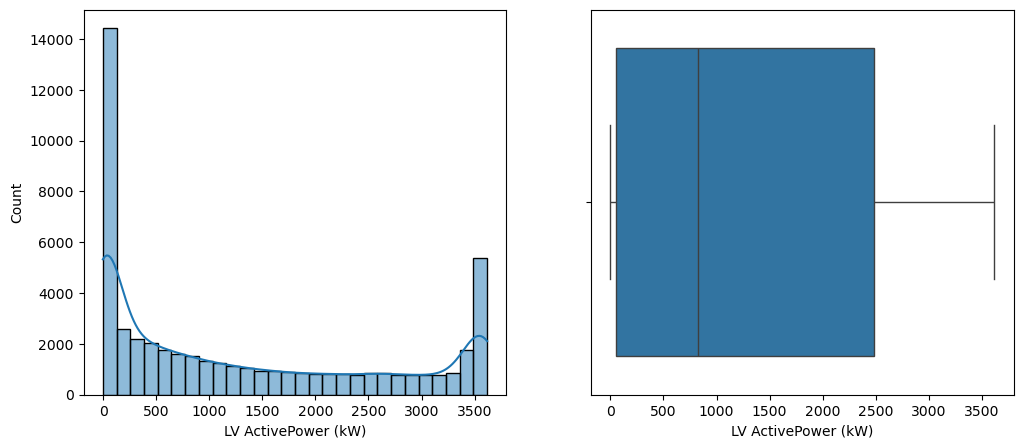

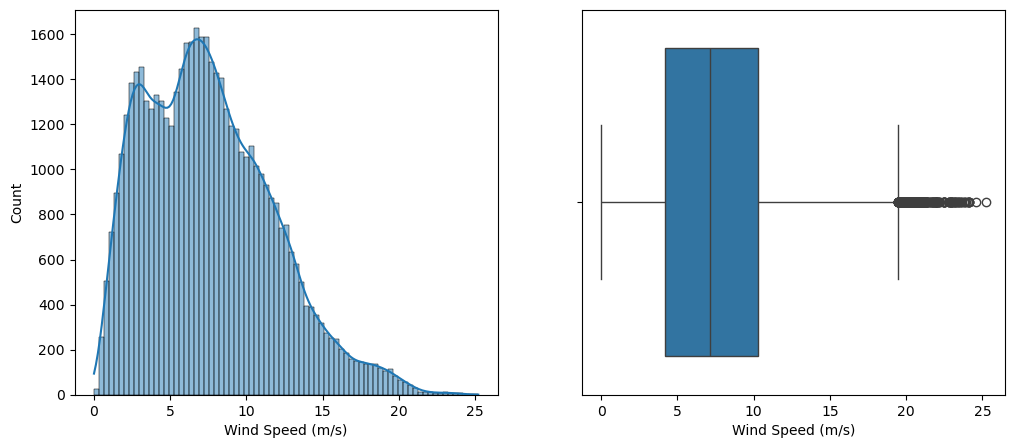

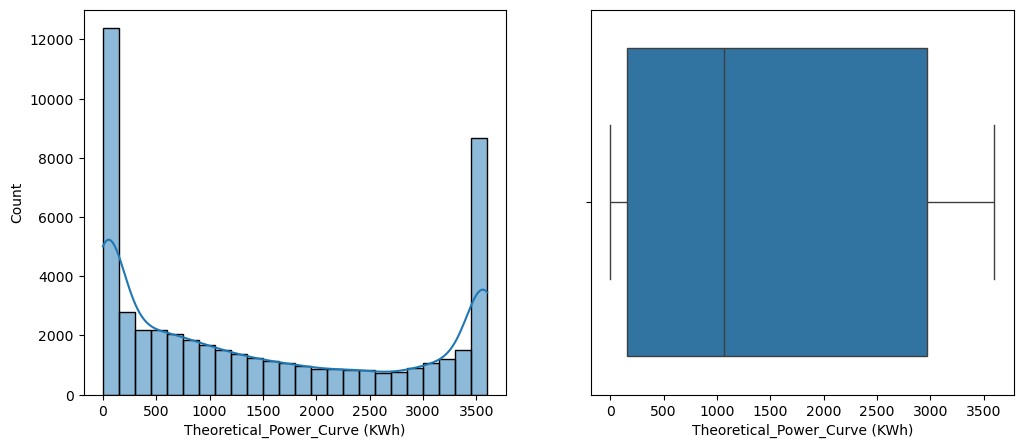

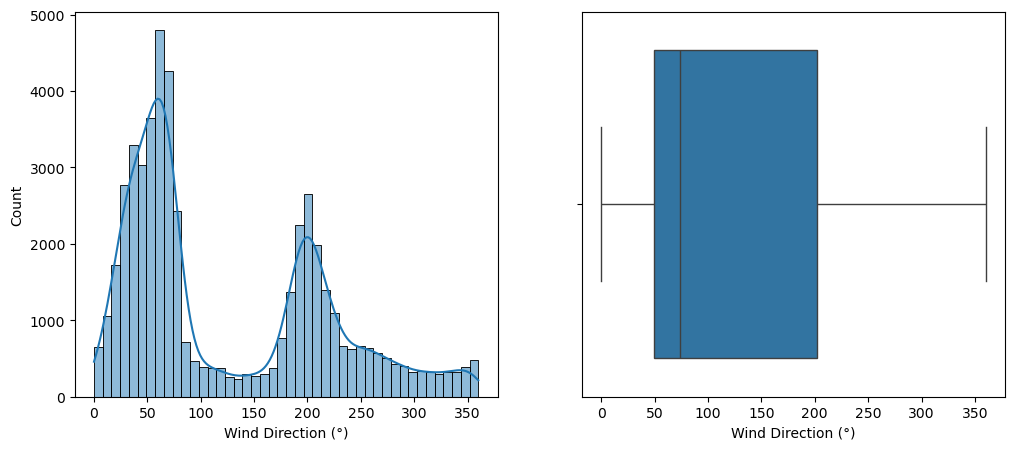

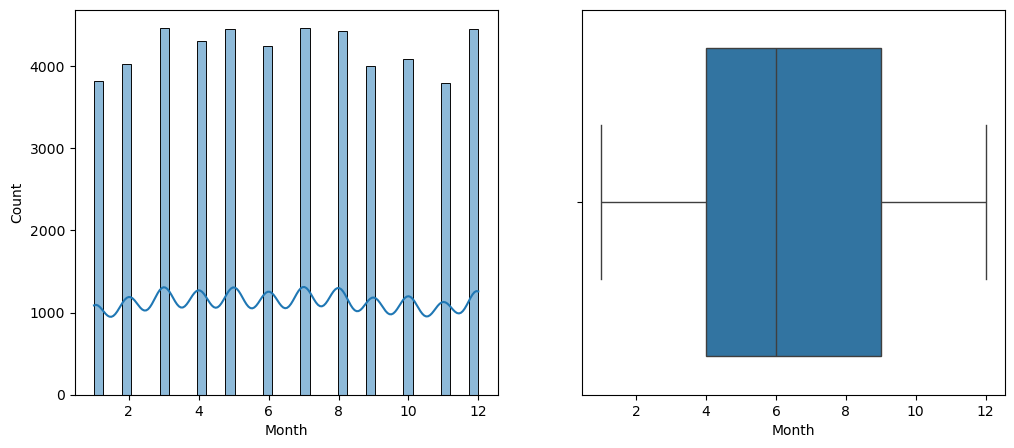

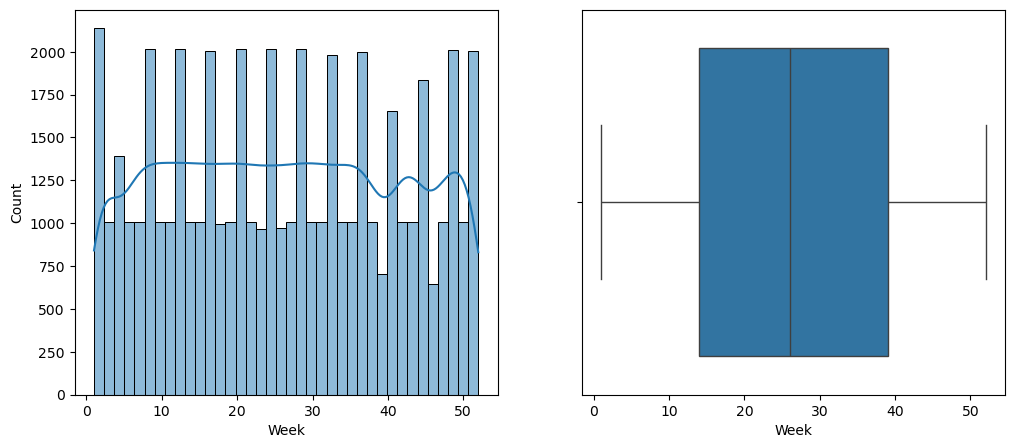

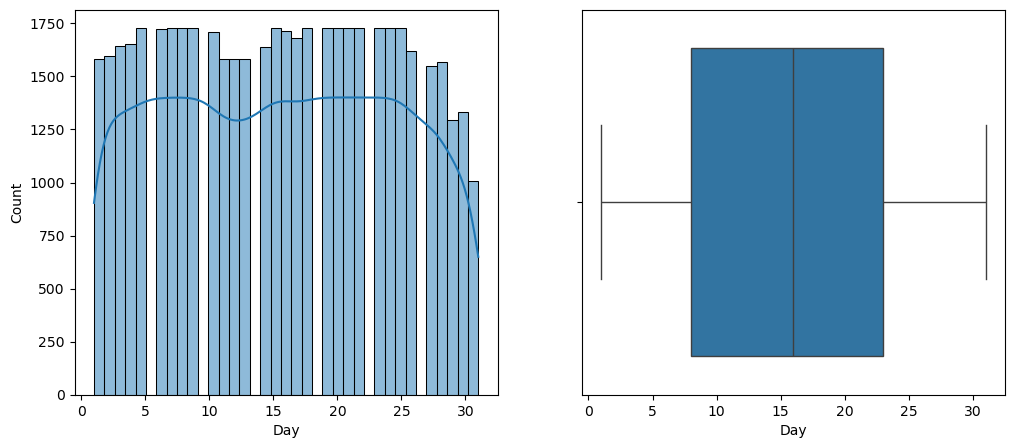

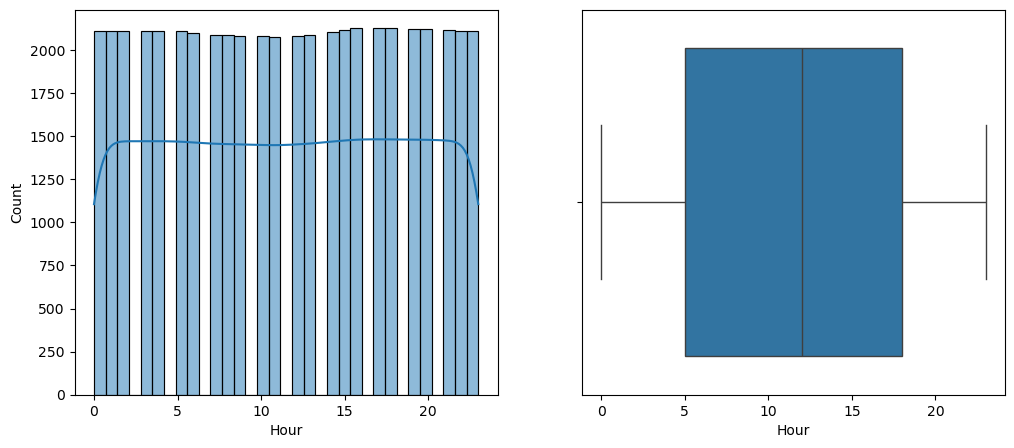

In [21]:
for col in df.describe().columns:
    fig, ax = plt.subplots(1,2, figsize=(12,5))
    sns.histplot(df[col], ax = ax[0], kde=True)
    sns.boxplot(x=df[col], ax = ax[1])

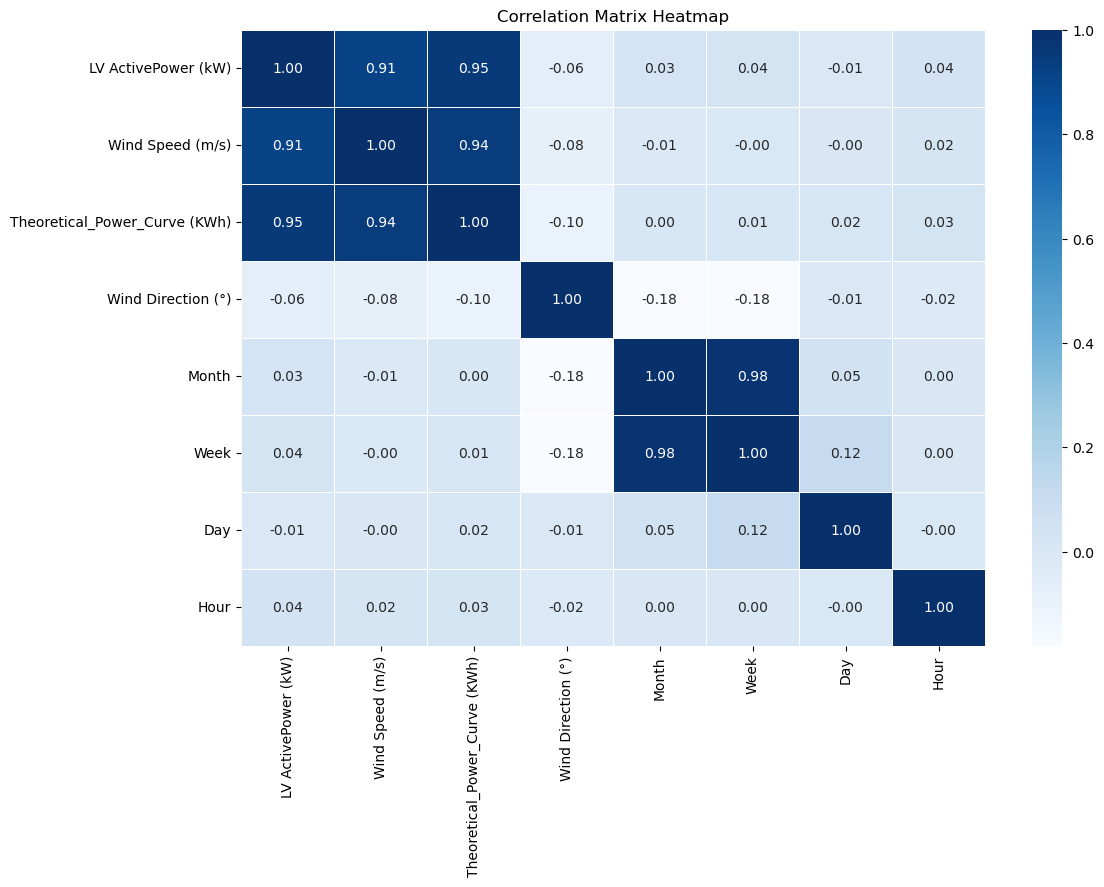

In [24]:
corr_matrix = df[numeric_columns].corr()
plt.figure(figsize =(12,8))
sns.heatmap(corr_matrix, annot = True, fmt ='.2f', cmap ='Blues', linewidths = 0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()